In [1]:
import warnings
warnings.filterwarnings("ignore")

# LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=key,
    max_tokens =  2048 , 
    temperature=0 , 
    reasoning_effort="low"
)

print(f"GROQ API key found: {bool(key)}")

GROQ API key found: True


In [2]:

# Pydantic
from pydantic import BaseModel


class GoalDefine(BaseModel):
    skills: list[str]
    roadmap: list[str]
    first_project: str


structured_llm = chat_model.with_structured_output(GoalDefine)

In [3]:
# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict

class StudentState(TypedDict):
    goal: str
    skills: list[str]
    roadmap: list[str]
    first_project: str

    task_plan: str
    priority_tasks: list[str]

    current_task: str
    completed_tasks: list[str]
    next_task: str
    progress: int

    student_status: str  

    messages: Annotated[list, add_messages]

In [4]:
# Goal Analysis Node
def analysis_goal(state: StudentState):

    goal = state["goal"]

    print(f"Goal: {goal}")
    prompt = f"""
Analyze this student's goal:

{goal}

Identify:

1. Required skills
2. Learning roadmap
3. First practical project

Make the roadmap practical and ordered.
"""
    response = structured_llm.invoke(prompt)

    return {
        "skills": response.skills,

        "roadmap": response.roadmap,

        "first_project": response.first_project,

        "messages": [
            (
                "assistant",
                f"Goal analysis completed for: {goal}"
            )
        ]
    }

In [5]:
# Project planer 
def project_planer(state:StudentState):
    project = state['first_project']
    prompt = f""" 
    Create a step-by-step implementation plan for this project:

{project}

Include:
1. Dataset
2. Data preprocessing
3. Model
4. Training
5. Evaluation
6. Deployment
"""

    response = chat_model.invoke(prompt) 
    return {
        "messages": [response]
    }

In [6]:
def task_planer(state: StudentState):

    prompt = f"""
You are an AI learning task planner.

Student goal:
{state["goal"]}

Required skills:
{state["skills"]}

Learning roadmap:
{state["roadmap"]}

First project:
{state["first_project"]}

Create a practical, ordered learning task plan.

Rules:
1. Start from beginner level.
2. Move toward advanced topics.
3. Make each task specific and actionable.
4. Include practical exercises.
5. Connect tasks to the first project where useful.
6. Do not create unnecessary topics.
7. Do not complete the tasks.
8. Return ONLY the task list.
"""

    response = chat_model.invoke(prompt)

    tasks = [
        line.strip("-•* ").strip()
        for line in response.content.split("\n")
        if line.strip() and line.strip()[0] not in ("#",)
    ]


    return {
        "task_plan": response.content,
        "priority_tasks":tasks,
        "messages": [response]
    }

In [7]:
# Task tracker 
def task_tracker(state: StudentState):

    tasks = state["priority_tasks"]
    completed_tasks = state.get("completed_tasks", [])

    if not tasks:
        return {
            "current_task": "",
            "completed_tasks": completed_tasks,
            "next_task": "",
            "progress": 0
        }

    current_index = len(completed_tasks)

    if current_index >= len(tasks):
        return {
            "current_task": "All tasks completed",
            "completed_tasks": completed_tasks,
            "next_task": "No more tasks left",
            "progress": 100
        }

    current_task = tasks[current_index]

    next_task = (
        tasks[current_index + 1]
        if current_index + 1 < len(tasks)
        else "No more tasks left"
    )

    progress = int(
        len(completed_tasks) / len(tasks) * 100
    )

    return {
        "current_task": current_task,
        "completed_tasks": completed_tasks,
        "next_task": next_task,
        "progress": progress
    }
    

In [8]:
class PriorityTasks(BaseModel):
    tasks: list[str]

priority_llm = chat_model.with_structured_output(PriorityTasks, method="json_mode")

def priority_planer(state: StudentState):
    prompt = f"""
Task plan summary (numbered items only):
{state["task_plan"][:1500]}

Extract and order the actionable, standalone tasks — one clear action per item.
Ignore headings and setup sub-bullets. Merge closely related steps.

First project: {state["first_project"]}

Return your answer as a JSON object with a "tasks" key containing the ordered list, 10-15 items maximum.
"""
    response = priority_llm.invoke(prompt)
    return {
        "priority_tasks": response.tasks,
        "messages": [("assistant", "Priority order set.")]
    }

In [9]:
def mark_progress(state: StudentState):
    if state.get("student_status") == "progressing" and state.get("current_task"):
        completed = state["completed_tasks"] + [state["current_task"]]
        return {"completed_tasks": completed}
    return {}

In [ ]:
def adaptive_planner(state: StudentState):
    prompt = f"""
The student is stuck on this task: {state["current_task"]}

Simplify it into 2-4 smaller, more achievable steps.
First project context: {state["first_project"]}

Return a JSON object with a "tasks" key containing only the simplified steps for this one task.
"""
    response = priority_llm.invoke(prompt)
    remaining_start = len(state["completed_tasks"])
    new_priority = (
        state["priority_tasks"][:remaining_start]
        + response.tasks
        + state["priority_tasks"][remaining_start + 1:]  # keep the rest of the plan intact
    )
    
    

In [11]:
def route_after_tracker(state: StudentState) -> str:
    if state["progress"] >= 100:
        return "final"
    if state.get("student_status") == "stuck":
        return "adaptive"
    return "final" if state["progress"] >= 100 else END  

In [12]:
def final_plan(state: StudentState):
    prompt = f"""
Summarize this student's completed learning journey into a clean final report:

Goal: {state["goal"]}
Skills covered: {state["skills"]}
All completed tasks: {state["completed_tasks"]}
First project: {state["first_project"]}

Write a short, encouraging summary and suggest one next-level goal beyond this roadmap.
"""
    response = chat_model.invoke(prompt)
    return {"messages": [response]}


### Memory Building 

In [13]:
!uv pip install langgraph-checkpoint-sqlite

Checked 1 package in 39ms


In [14]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3 
conn = sqlite3.connect("student_memory.db",check_same_thread=False)
checkpointer = SqliteSaver(conn)
checkpointer.setup()


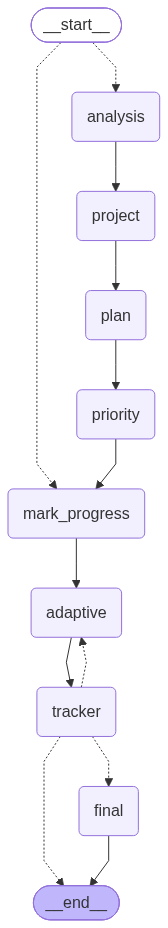

In [15]:
# Build Graph

graph = StateGraph(StudentState)

graph.add_node("analysis", analysis_goal)
graph.add_node("project", project_planer)
graph.add_node("plan", task_planer)
graph.add_node("priority", priority_planer) 
graph.add_node("tracker", task_tracker)
graph.add_node("mark_progress", mark_progress)
graph.add_node("adaptive", adaptive_planner)
graph.add_node("final",final_plan)

def route_from_start(state: StudentState) -> str:
    if state.get("priority_tasks"):
        return "mark_progress"
    return "analysis"

graph.add_conditional_edges(
    START,
    route_from_start,
    {"analysis": "analysis", "mark_progress": "mark_progress"}
)
graph.add_edge("analysis", "project")
graph.add_edge("project", "plan")
graph.add_edge("plan", "priority")            
graph.add_edge("priority", "mark_progress") 
graph.add_edge("mark_progress","adaptive")
graph.add_edge("adaptive", "tracker")
graph.add_conditional_edges(
    "tracker",
    route_after_tracker,
    {"adaptive": "adaptive", "final": "final", END: END}
)
graph.add_edge("final", END)



# Compile
app = graph.compile(checkpointer=checkpointer)

app

In [16]:
config = {"configurable": {"thread_id": "student_debajyoti_003"}}

# Call 1 — normal start
result1 = app.invoke({
    "goal": "I want to become an ML engineer",
    "skills": [], "roadmap": [], "first_project": "",
    "task_plan": "", "priority_tasks": [],
    "current_task": "", "completed_tasks": [], "next_task": "",
    "progress": 0, "student_status": "progressing",
    "messages": [("human", "I want to become an ML engineer")]
}, config=config)

print("Call 1 current:", result1["current_task"])

# Call 2 — student is stuck on it
result2 = app.invoke({"student_status": "stuck"}, config=config)

print("Call 2 current (should be a simplified version of call 1's task):", result2["current_task"])
print("Call 2 priority_tasks[0:2] (should differ from original):", result2["priority_tasks"][:2])

Goal: I want to become an ML engineer
Call 1 current: Collect and label a small set of product reviews
Call 2 current (should be a simplified version of call 1's task): Collect a small sample of product reviews (e.g., 20–30 reviews).
Call 2 priority_tasks[0:2] (should differ from original): ['Collect a small sample of product reviews (e.g., 20–30 reviews).', 'Label each review with a sentiment tag (positive, negative, neutral).']


In [17]:
result2 = app.invoke({
    "student_status": "progressing"
}, config=config)

print("Completed tasks:", result2["completed_tasks"])
print("Current task:", result2["current_task"])

Completed tasks: ['Collect a small sample of product reviews (e.g., 20–30 reviews).']
Current task: Collect 20–30 product reviews from a single source (e.g., Amazon, Yelp, or a public dataset).
